In [1]:
%load_ext autoreload
%autoreload 2
%cd ../../..
from rich import print



/mnt/d/project-equinox


In [2]:
case_dir = "data/cases/LGAV_LFPG/"
batch_sgd_results_dir_path = f"{case_dir}results_nogaugezeroridge/"

In [3]:
# Look for the latest checkpoint in the `batch_sgd_results_dir_path`
import re
from pathlib import Path

def get_latest_checkpoint(results_dir_path):
    directory = Path(results_dir_path)
    
    # Pattern to match 'checkpoint_iter_X.pt' and capture X
    pattern = re.compile(r"checkpoint_iter_(\d+)\.pt")
    
    checkpoints = []
    
    # Iterate through files in the directory
    for file in directory.glob("checkpoint_iter_*.pt"):
        match = pattern.search(file.name)
        if match:
            iteration = int(match.group(1))
            checkpoints.append((iteration, file.name))
            
    if not checkpoints:
        return None
    
    # Sort by the iteration number (the first element of the tuple) and get the last one
    latest_checkpoint = max(checkpoints, key=lambda x: x[0])
    
    return latest_checkpoint[1]


latest_checkpoint_filename = batch_sgd_results_dir_path + get_latest_checkpoint(batch_sgd_results_dir_path)
print(f"Latest checkpoint: {latest_checkpoint_filename}")

Latest checkpoint: data/cases/LGAV_LFPG/results_nogaugezeroridge/checkpoint_iter_350.pt

In [4]:
from equinox.posttrain import load_cost_model_parameters
from rich.console import Console
from rich.table import Table

def print_params_table(params_dict):
    console = Console()
    
    # Initialize the table
    table = Table(title="Common Parameters", show_header=True, header_style="bold magenta")
    
    table.add_column("Parameter", style="dim", width=12)
    table.add_column("Value", justify="right")

    # Add rows, formatting floats to 6 decimal places for clarity
    for key, value in params_dict.items():
        table.add_row(key, f"{value:.6f}")

    console.print(table)

params = load_cost_model_parameters(latest_checkpoint_filename)
print("[bold red]Parameters retrieved from learned cost model[/bold red]")
print_params_table(params["common"])
print(params["preference_matrix"].shape)  # (num_nodes, num_nodes)

Parameters retrieved from learned cost model

     Common Parameters     
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Parameter    ┃    Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ bias         │ 0.257323 │
│ ac_dist      │ 0.000125 │
│ time         │ 0.029689 │
└──────────────┴──────────┘

torch.Size([600, 600])

Loading route graph from /mnt/d/project-equinox/data/cases/LGAV_LFPG/graphs/routes.gml

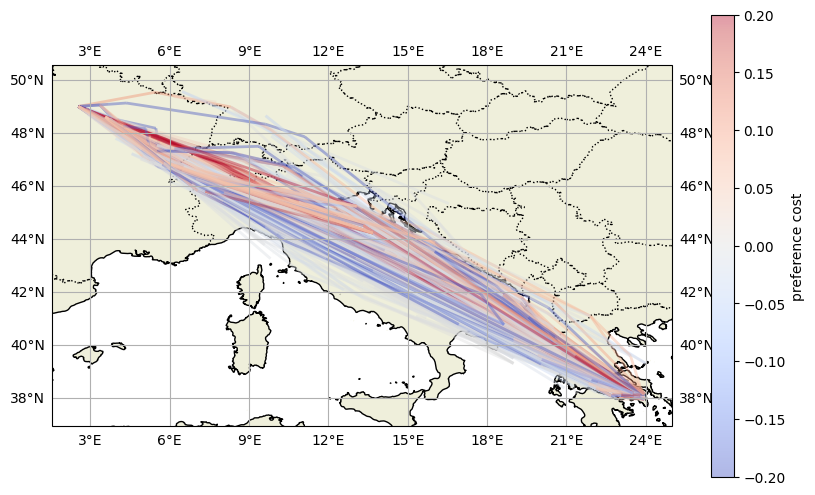

<GeoAxes: >

In [25]:
from equinox.posttrain import load_checkpoint_edge_preferences, plot_edge_preferences_cartopy

from pathlib import Path

def get_gml_path(batch_sgd_results_dir_path: str) -> str:
    """
    Recursively searches for a .gml file in the specified directory.
    Returns the absolute path to the .gml file.
    """
    directory = Path(batch_sgd_results_dir_path)
    
    # rglob("*.gml") searches recursively for all files ending in .gml
    # We use next() to get the first result since only one is guaranteed.
    try:
        gml_file = next(directory.rglob("*.gml"))
        return str(gml_file.absolute())
    except StopIteration:
        raise FileNotFoundError(f"No .gml file found in {batch_sgd_results_dir_path}")

gml_path = get_gml_path(case_dir)
print(f'Loading route graph from {gml_path}')

payload = load_checkpoint_edge_preferences(latest_checkpoint_filename, gml_path)
plot_edge_preferences_cartopy(
    payload["graph"],
    edge_preferences=payload["edge_preferences"],
    cmap="coolwarm",
    linewidth=2,
    alpha=0.4,
    percentile=0.5,
    percentile_mode="contrast", # upper = more preferred, lower = less preferred, contrast = half lowest, half highest
    preference_color_range=(-0.2,0.2)
)

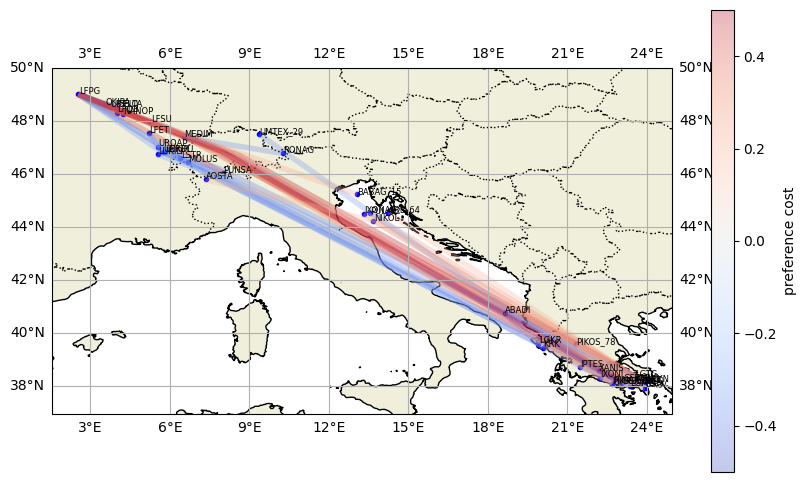

<GeoAxes: >

In [24]:
plot_edge_preferences_cartopy(
    payload["graph"],
    edge_preferences=payload["edge_preferences"],
    cmap="coolwarm",
    linewidth=4,
    alpha=0.3,
    percentile=0.02,
    percentile_mode="contrast", # upper = more preferred, lower = less preferred, contrast = half lowest, half highest
    preference_color_range=(-0.5,0.5),
    show_waypoints=True
)

# Raw prior route traversal frequency

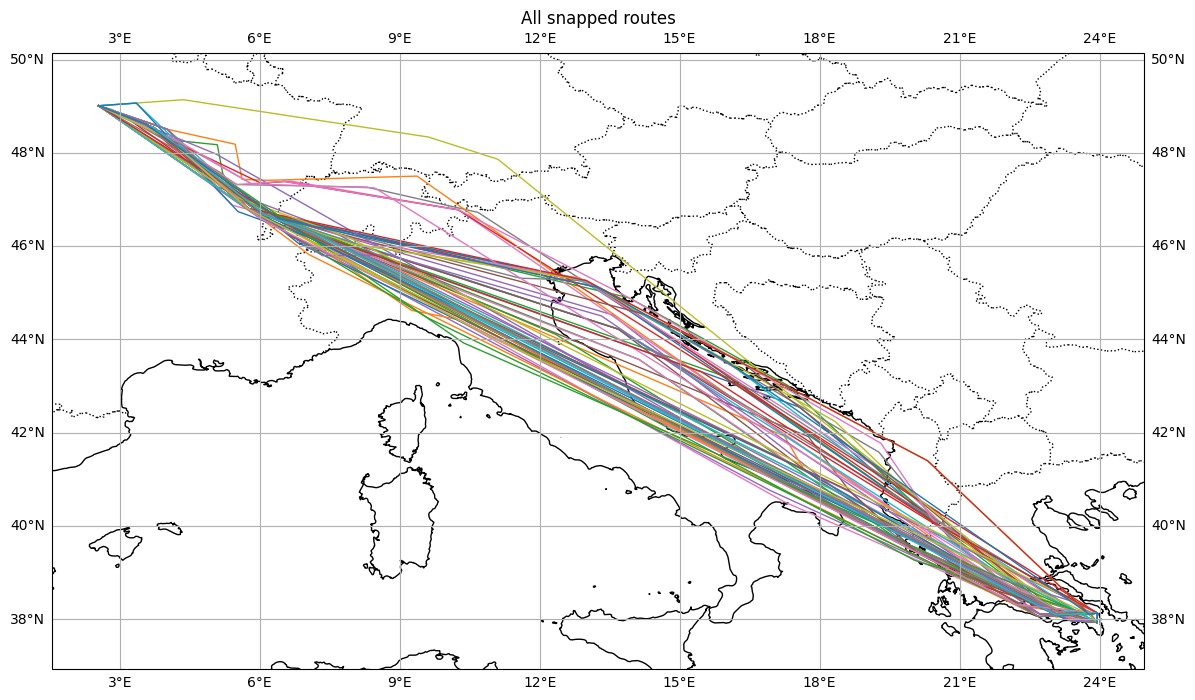

(<Figure size 1800x800 with 1 Axes>,
 <GeoAxes: title={'center': 'All snapped routes'}>)

In [7]:
from equinox.posttrain.plot_sample_routes import plot_snapped_routes
plot_snapped_routes(case_dir=Path("data/cases/LGAV_LFPG"), show_waypoints=False)

# Route cost decomposition and inspection

In [20]:
from equinox.posttrain.cost_back_envelope import compute_route_cost_breakdown, breakdown_to_frame

reference_flight_id = "392AF8AFR98CQ"
reference_takeoff_timestamp = 1682696720

result = compute_route_cost_breakdown(
    checkpoint_path=latest_checkpoint_filename,
    case_dir=case_dir,
    flight_id=reference_flight_id,
    takeoff_time=reference_takeoff_timestamp
)

df = breakdown_to_frame(result["breakdown"])
print_params_table(result["totals"])
df


All components initialized successfully:
  - Graph loaded with 600 nodes
  - Origin: LGAV (idx: 174)
  - Goal: LFPG (idx: 95)
  - Device: cpu
  - Distance matrix shape: (600, 600)
  - Charges matrix shape: (600, 600)


     Common Parameters      
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Parameter    ┃     Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ cost_bias    │  1.286614 │
│ cost_ac_dist │  0.097889 │
│ cost_time    │  5.292541 │
│ cost_prefer… │ -1.211677 │
│ cost_common  │  6.677043 │
│ cost_total   │  5.465367 │
└──────────────┴───────────┘

,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,LGKN,174,200,12.129164,25.460000,-17.075373,False,1.0,3.088085,1.681008,0.257323,0.000125,0.029689,0.257323,0.000386,0.049907,-0.069579,0.307615,0.238036
1,LGKN,GERMI,200,229,39.142533,25.460000,-22.265616,False,1.0,9.965689,5.490678,0.257323,0.000125,0.029689,0.257323,0.001245,0.163010,-0.271276,0.421578,0.150302
2,GERMI,ODNUP,229,244,872.220320,64.667316,-64.602303,False,1.0,564.041470,135.790171,0.257323,0.000125,0.029689,0.257323,0.070457,4.031417,-0.236791,4.359196,4.122406
3,ODNUP,URELO,244,221,185.902411,87.538265,-45.108929,False,1.0,162.735745,27.548507,0.257323,0.000125,0.029689,0.257323,0.020328,0.817876,-0.217860,1.095527,0.877666
4,URELO,LFPG,221,95,54.726358,80.070000,-26.761257,False,1.0,43.819395,7.758225,0.257323,0.000125,0.029689,0.257323,0.005474,0.230331,-0.416171,0.493127,0.076956


# Inference/Sampling

In [21]:
from pathlib import Path 

from equinox.sampling.pipeline import compute_4d_path_for_dataset
from equinox.posttrain.plot_sample_routes import plot_sample_routes

res = compute_4d_path_for_dataset(
    case_dir=Path("data/cases/LGAV_LFPG"),
    checkpoint_path=Path(latest_checkpoint_filename),
    flight_id=reference_flight_id,
    takeoff_timestamp=reference_takeoff_timestamp,
    n_samples=100,
    policy="sample",
    output_dir=Path(f"data/cases/LGAV_LFPG/inference_flight_{reference_flight_id}"),
    seed=7,
)

All components initialized successfully:
  - Graph loaded with 600 nodes
  - Origin: LGAV (idx: 174)
  - Goal: LFPG (idx: 95)
  - Device: cpu
  - Distance matrix shape: (600, 600)
  - Charges matrix shape: (600, 600)
Goal LFPG reached at step 4.
Goal LFPG reached at step 9.
Goal LFPG reached at step 5.
Goal LFPG reached at step 5.
Goal LFPG reached at step 7.
Goal LFPG reached at step 5.
Goal LFPG reached at step 5.
Goal LFPG reached at step 8.
Goal LFPG reached at step 5.
Goal LFPG reached at step 7.
Goal LFPG reached at step 5.
Goal LFPG reached at step 7.
Goal LFPG reached at step 4.
Goal LFPG reached at step 4.
Goal LFPG reached at step 9.
Goal LFPG reached at step 6.
Goal LFPG reached at step 5.
Goal LFPG reached at step 6.
Goal LFPG reached at step 7.
Goal LFPG reached at step 4.
Goal LFPG reached at step 5.
Goal LFPG reached at step 4.
Goal LFPG reached at step 5.
Goal LFPG reached at step 3.
Goal LFPG reached at step 5.
Goal LFPG reached at step 4.
Goal LFPG reached at step 6.


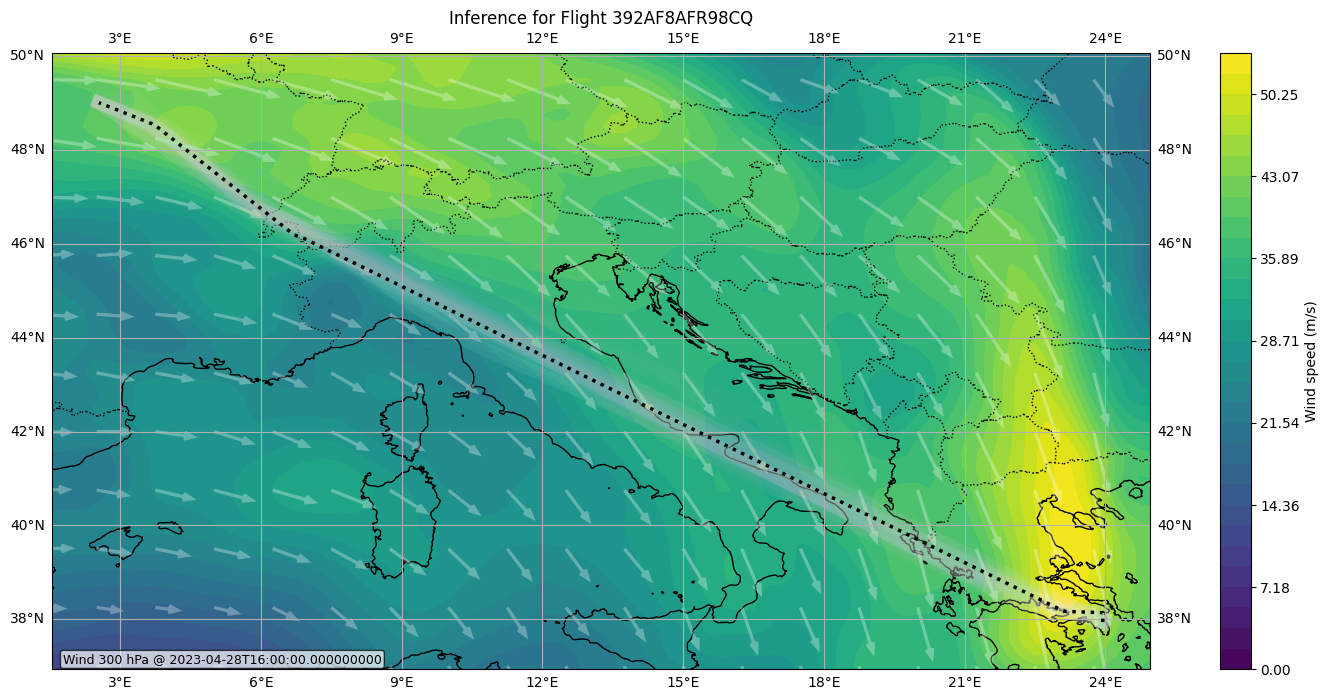

(<Figure size 1800x800 with 2 Axes>,
 <GeoAxes: title={'center': 'Inference for Flight 392AF8AFR98CQ'}>)

In [22]:

plot_sample_routes(
    case_dir=Path("data/cases/LGAV_LFPG"),
    routes_path=Path(f"data/cases/LGAV_LFPG/inference_flight_{reference_flight_id}/routes.txt"),
    show=True,
    show_waypoints=False,
    route_alpha=0.01,
    reference_flight_id=reference_flight_id,
    reference_takeoff_timestamp=reference_takeoff_timestamp,
    plot_wind = True,
    show_quiver = True,
    thickness = 10,
    plot_title=f"Inference for Flight {reference_flight_id}"
)

All components initialized successfully:
  - Graph loaded with 600 nodes
  - Origin: LGAV (idx: 174)
  - Goal: LFPG (idx: 95)
  - Device: cpu
  - Distance matrix shape: (600, 600)
  - Charges matrix shape: (600, 600)
Route 1/10: LGAV -> XORKI -> OLKIS -> OKIPA -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,XORKI,174,560,24.887,25.460,-31.595,False,1.0,6.336,3.569,0.257,0.0,0.03,0.257,0.001,0.106,-0.167,0.364,0.197
1,XORKI,OLKIS,560,342,686.832,57.790,-60.755,False,1.0,396.924,105.871,0.257,0.0,0.03,0.257,0.050,3.143,-0.294,3.450,3.156
2,OLKIS,OKIPA,342,232,398.390,91.002,-45.382,False,1.0,362.542,59.077,0.257,0.0,0.03,0.257,0.045,1.754,-0.267,2.057,1.789
3,OKIPA,LFPG,232,95,46.745,80.070,-25.558,False,1.0,37.429,6.608,0.257,0.0,0.03,0.257,0.005,0.196,-0.418,0.458,0.040


Totals: bias=1.029, ac_dist=0.100, time=5.199, preference=-1.146, total=5.183


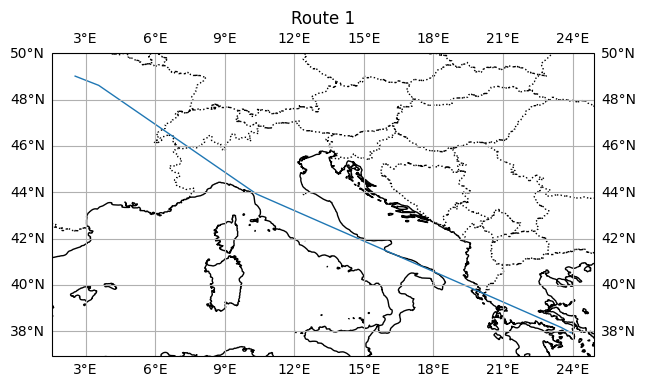

Route 2/10: LGAV -> LGEL -> IPTES -> LSTR -> URELO -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,LGEL,174,1,19.906,25.460,-17.626,False,1.0,5.068,2.762,0.257,0.0,0.03,0.257,0.001,0.082,-0.061,0.340,0.279
1,LGEL,IPTES,1,215,104.835,25.460,-48.954,False,1.0,26.691,15.684,0.257,0.0,0.03,0.257,0.003,0.466,-0.314,0.726,0.412
2,IPTES,LSTR,215,272,814.807,72.697,-57.691,False,1.0,592.340,124.617,0.257,0.0,0.03,0.257,0.074,3.700,-0.258,4.031,3.773
3,LSTR,URELO,272,221,159.275,84.336,-47.149,False,1.0,134.326,23.722,0.257,0.0,0.03,0.257,0.017,0.704,-0.219,0.978,0.759
4,URELO,LFPG,221,95,54.726,80.070,-26.761,False,1.0,43.819,7.758,0.257,0.0,0.03,0.257,0.005,0.230,-0.416,0.493,0.077


Totals: bias=1.287, ac_dist=0.100, time=5.182, preference=-1.268, total=5.300


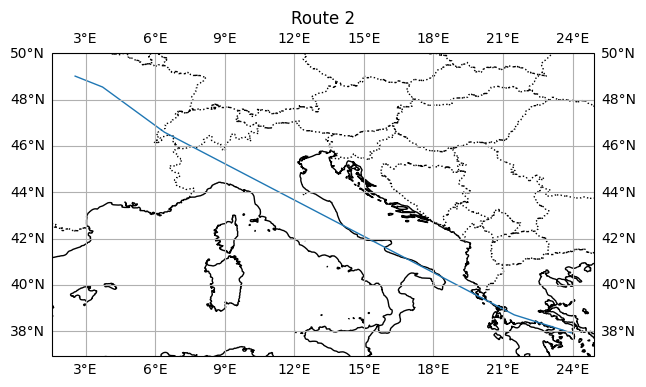

Route 3/10: LGAV -> LGKN -> RIMAX -> LIBV -> ARBOS_89 -> LFQB -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,LGKN,174,200,12.129,25.460,-17.075,False,1.0,3.088,1.681,0.257,0.0,0.03,0.257,0.000,0.050,-0.070,0.308,0.238
1,LGKN,RIMAX,200,230,58.380,25.460,-19.678,False,1.0,14.863,8.140,0.257,0.0,0.03,0.257,0.002,0.242,-0.294,0.501,0.207
2,RIMAX,LIBV,230,593,311.687,43.029,-58.941,False,1.0,134.117,47.822,0.257,0.0,0.03,0.257,0.017,1.420,-0.275,1.694,1.419
3,LIBV,ARBOS_89,593,44,588.215,81.136,-53.668,False,1.0,477.254,89.049,0.257,0.0,0.03,0.257,0.060,2.644,-0.280,2.961,2.681
4,ARBOS_89,LFQB,44,79,131.814,80.074,-44.321,False,1.0,105.549,19.495,0.257,0.0,0.03,0.257,0.013,0.579,-0.288,0.849,0.561
5,LFQB,LFPG,79,95,71.408,80.070,-28.137,False,1.0,57.176,10.156,0.257,0.0,0.03,0.257,0.007,0.302,-0.367,0.566,0.199


Totals: bias=1.544, ac_dist=0.099, time=5.235, preference=-1.573, total=5.305


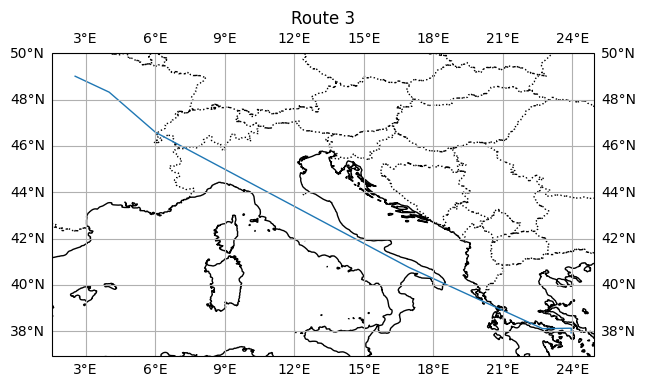

Route 4/10: LGAV -> LGKN -> IXONI -> KRK -> ARBOS_89 -> LFQB -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,LGKN,174,200,12.129,25.460,-17.075,False,1.0,3.088,1.681,0.257,0.0,0.03,0.257,0.000,0.050,-0.070,0.308,0.238
1,LGKN,IXONI,200,148,81.838,25.460,-28.588,False,1.0,20.836,11.652,0.257,0.0,0.03,0.257,0.003,0.346,-0.346,0.606,0.260
2,IXONI,KRK,148,234,121.571,25.460,-57.646,False,1.0,30.952,18.591,0.257,0.0,0.03,0.257,0.004,0.552,-0.202,0.813,0.612
3,KRK,ARBOS_89,234,44,749.897,76.281,-54.928,False,1.0,572.029,113.888,0.257,0.0,0.03,0.257,0.071,3.381,-0.259,3.710,3.451
4,ARBOS_89,LFQB,44,79,131.814,80.074,-44.321,False,1.0,105.549,19.495,0.257,0.0,0.03,0.257,0.013,0.579,-0.288,0.849,0.561
5,LFQB,LFPG,79,95,71.408,80.070,-28.137,False,1.0,57.176,10.156,0.257,0.0,0.03,0.257,0.007,0.302,-0.367,0.566,0.199


Totals: bias=1.544, ac_dist=0.099, time=5.209, preference=-1.531, total=5.321


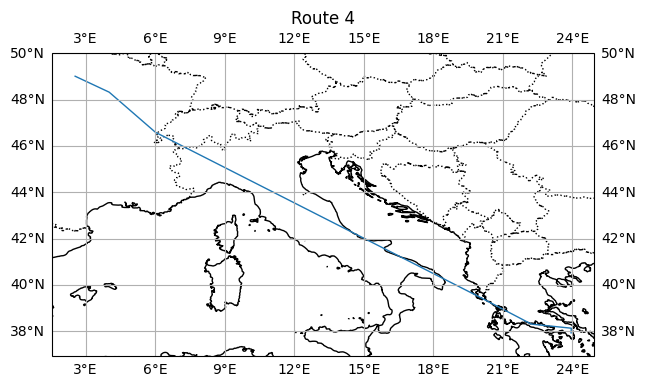

Route 5/10: LGAV -> XORKI -> DINOX -> URELO -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,XORKI,174,560,24.887,25.460,-31.595,False,1.0,6.336,3.569,0.257,0.0,0.03,0.257,0.001,0.106,-0.167,0.364,0.197
1,XORKI,DINOX,560,298,921.118,69.197,-65.789,False,1.0,637.386,143.846,0.257,0.0,0.03,0.257,0.080,4.271,-0.226,4.608,4.381
2,DINOX,URELO,298,221,148.236,80.076,-45.100,False,1.0,118.701,21.966,0.257,0.0,0.03,0.257,0.015,0.652,-0.221,0.924,0.704
3,URELO,LFPG,221,95,54.726,80.070,-26.761,False,1.0,43.819,7.758,0.257,0.0,0.03,0.257,0.005,0.230,-0.416,0.493,0.077


Totals: bias=1.029, ac_dist=0.101, time=5.259, preference=-1.030, total=5.359


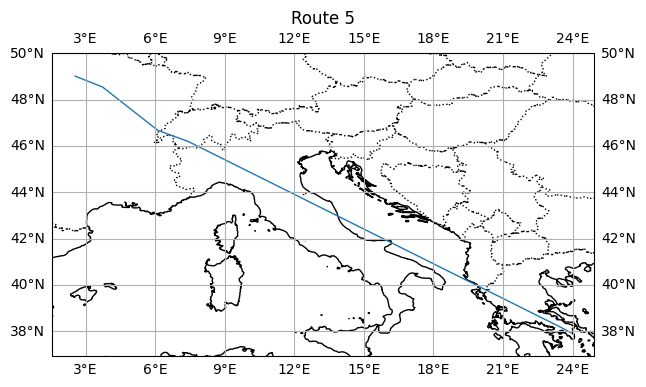

Route 6/10: LGAV -> LGKN -> RIMAX -> LIBV -> ARBOS_89 -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,LGKN,174,200,12.129,25.460,-17.075,False,1.0,3.088,1.681,0.257,0.0,0.03,0.257,0.000,0.050,-0.070,0.308,0.238
1,LGKN,RIMAX,200,230,58.380,25.460,-19.678,False,1.0,14.863,8.140,0.257,0.0,0.03,0.257,0.002,0.242,-0.294,0.501,0.207
2,RIMAX,LIBV,230,593,311.687,43.029,-58.941,False,1.0,134.117,47.822,0.257,0.0,0.03,0.257,0.017,1.420,-0.275,1.694,1.419
3,LIBV,ARBOS_89,593,44,588.215,81.136,-53.668,False,1.0,477.254,89.049,0.257,0.0,0.03,0.257,0.060,2.644,-0.280,2.961,2.681
4,ARBOS_89,LFPG,44,95,201.548,80.081,-27.095,False,1.0,161.402,28.595,0.257,0.0,0.03,0.257,0.020,0.849,-0.291,1.126,0.835


Totals: bias=1.287, ac_dist=0.099, time=5.204, preference=-1.209, total=5.380


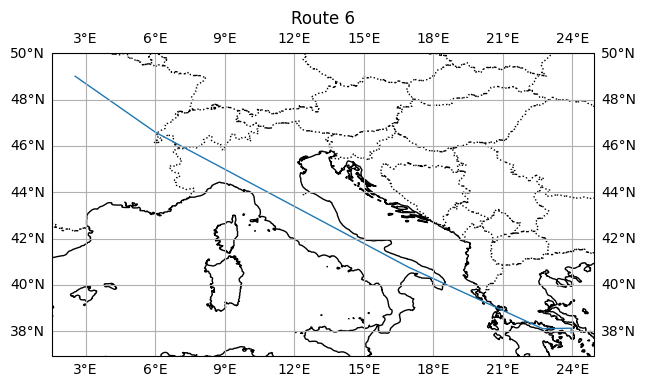

Route 7/10: LGAV -> GERMI -> LUKID -> LFFH -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,GERMI,174,229,41.135,25.460,-25.606,False,1.0,10.473,5.816,0.257,0.0,0.03,0.257,0.001,0.173,-0.119,0.431,0.312
1,GERMI,LUKID,229,147,930.687,66.326,-63.551,False,1.0,617.289,144.498,0.257,0.0,0.03,0.257,0.077,4.290,-0.323,4.624,4.301
2,LUKID,LFFH,147,84,164.826,80.076,-35.212,False,1.0,131.986,23.842,0.257,0.0,0.03,0.257,0.016,0.708,-0.301,0.982,0.681
3,LFFH,LFPG,84,95,31.977,80.070,-22.714,False,1.0,25.604,4.490,0.257,0.0,0.03,0.257,0.003,0.133,-0.308,0.394,0.086


Totals: bias=1.029, ac_dist=0.098, time=5.304, preference=-1.051, total=5.380


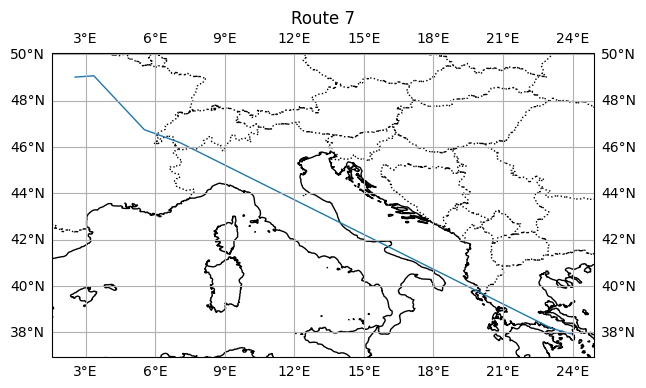

Route 8/10: LGAV -> RIMAX -> LIBV -> ARBOS_89 -> LFQB -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,RIMAX,174,230,59.075,25.460,-20.767,False,1.0,15.040,8.258,0.257,0.0,0.03,0.257,0.002,0.245,0.017,0.504,0.521
1,RIMAX,LIBV,230,593,311.687,43.029,-58.941,False,1.0,134.117,47.822,0.257,0.0,0.03,0.257,0.017,1.420,-0.275,1.694,1.419
2,LIBV,ARBOS_89,593,44,588.215,81.136,-53.668,False,1.0,477.254,89.049,0.257,0.0,0.03,0.257,0.060,2.644,-0.280,2.961,2.681
3,ARBOS_89,LFQB,44,79,131.814,80.074,-44.321,False,1.0,105.549,19.495,0.257,0.0,0.03,0.257,0.013,0.579,-0.288,0.849,0.561
4,LFQB,LFPG,79,95,71.408,80.070,-28.137,False,1.0,57.176,10.156,0.257,0.0,0.03,0.257,0.007,0.302,-0.367,0.566,0.199


Totals: bias=1.287, ac_dist=0.099, time=5.189, preference=-1.193, total=5.382


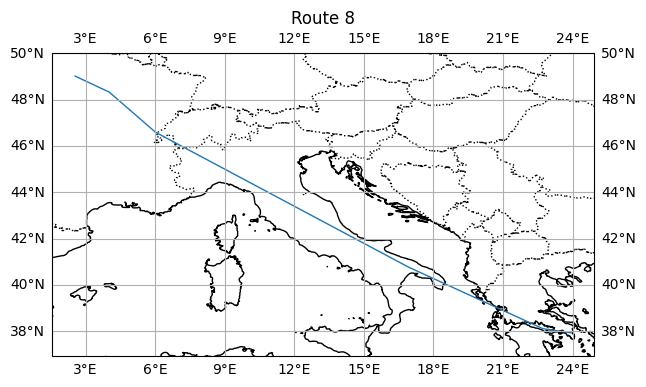

Route 9/10: LGAV -> GERMI -> PIKEL -> LSTR -> URELO -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,GERMI,174,229,41.135,25.460,-25.606,False,1.0,10.473,5.816,0.257,0.0,0.03,0.257,0.001,0.173,-0.119,0.431,0.312
1,GERMI,PIKEL,229,5,329.817,41.459,-62.833,False,1.0,136.741,51.112,0.257,0.0,0.03,0.257,0.017,1.517,-0.218,1.792,1.574
2,PIKEL,LSTR,5,272,566.690,84.286,-57.844,False,1.0,477.641,86.704,0.257,0.0,0.03,0.257,0.060,2.574,-0.224,2.891,2.667
3,LSTR,URELO,272,221,159.275,84.336,-47.149,False,1.0,134.326,23.722,0.257,0.0,0.03,0.257,0.017,0.704,-0.219,0.978,0.759
4,URELO,LFPG,221,95,54.726,80.070,-26.761,False,1.0,43.819,7.758,0.257,0.0,0.03,0.257,0.005,0.230,-0.416,0.493,0.077


Totals: bias=1.287, ac_dist=0.100, time=5.199, preference=-1.197, total=5.389


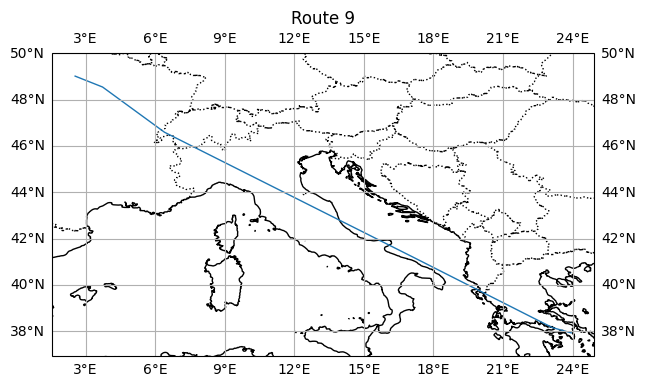

Route 10/10: LGAV -> GERMI -> DJL -> OKIPA -> LFPG


,u_node,v_node,u_idx,v_idx,distance,airspace_charge,tailwind_kts,tailwind_is_fallback,feature_bias,feature_ac_dist,feature_time,weight_bias,weight_ac_dist,weight_time,cost_bias,cost_ac_dist,cost_time,cost_preference,cost_common,cost_total
0,LGAV,GERMI,174,229,41.135,25.460,-25.606,False,1.0,10.473,5.816,0.257,0.0,0.03,0.257,0.001,0.173,-0.119,0.431,0.312
1,GERMI,DJL,229,330,961.284,70.685,-65.428,False,1.0,679.484,149.977,0.257,0.0,0.03,0.257,0.085,4.453,-0.245,4.795,4.549
2,DJL,OKIPA,330,232,101.405,80.072,-42.284,False,1.0,81.197,14.923,0.257,0.0,0.03,0.257,0.010,0.443,-0.220,0.711,0.490
3,OKIPA,LFPG,232,95,46.745,80.070,-25.558,False,1.0,37.429,6.608,0.257,0.0,0.03,0.257,0.005,0.196,-0.418,0.458,0.040


Totals: bias=1.029, ac_dist=0.101, time=5.264, preference=-1.003, total=5.392


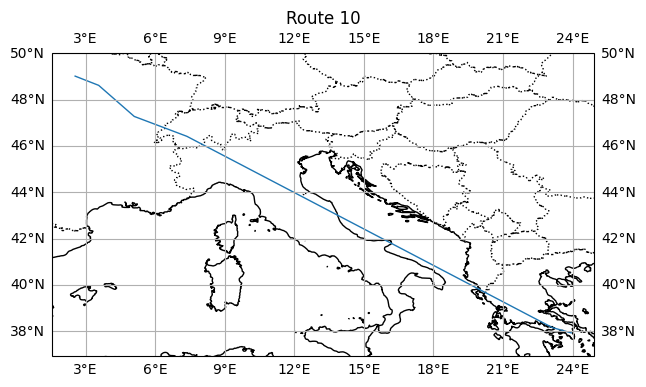

[{'route_nodes': ['LGAV', 'XORKI', 'OLKIS', 'OKIPA', 'LFPG'],
  'breakdown': [{'u_node': 'LGAV',
    'v_node': 'XORKI',
    'u_idx': 174,
    'v_idx': 560,
    'distance': 24.88671886688848,
    'airspace_charge': 25.46,
    'tailwind_kts': -31.595158576965332,
    'tailwind_is_fallback': False,
    'feature_bias': 1.0,
    'feature_ac_dist': 6.336158623509807,
    'feature_time': 3.568799842121288,
    'weight_bias': 0.2573227286338806,
    'weight_ac_dist': 0.00012491439701989293,
    'weight_time': 0.029688576236367226,
    'cost_bias': 0.2573227286338806,
    'cost_ac_dist': 0.0007914774338781223,
    'cost_time': 0.10595258618515319,
    'cost_preference': -0.166754350066185,
    'cost_common': 0.36406679225291194,
    'cost_total': 0.19731244218672694},
   {'u_node': 'XORKI',
    'v_node': 'OLKIS',
    'u_idx': 560,
    'v_idx': 342,
    'distance': 686.8324428787682,
    'airspace_charge': 57.79047209777579,
    'tailwind_kts': -60.75489807128906,
    'tailwind_is_fallback': Fal

In [23]:
from equinox.posttrain.cost_back_envelope import compute_routes_cost_breakdowns


compute_routes_cost_breakdowns(
    checkpoint_path=latest_checkpoint_filename,
    case_dir=case_dir,
    flight_id=reference_flight_id,
    takeoff_time=reference_takeoff_timestamp,
    routes_path=Path(f"data/cases/LGAV_LFPG/inference_flight_{reference_flight_id}/routes.txt"),
    limit=10
)